In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
current_pwd = os.getcwd()

possible_paths = [
    '/home/export/soheuny/SRFinder/soheun/notebooks', 
    '/home/soheuny/HH4bsim/soheun/notebooks'
]
    
assert os.getcwd() in possible_paths, f"Did you change the path? It should be one of {possible_paths}"
os.chdir("..")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import torch
import tqdm

from plots import hist_events_by_labels
from events_data import EventsData
from fvt_classifier import FvTClassifier
# import LogNorm
from matplotlib.colors import LogNorm
from training_info import TrainingInfo
from plots import plot_rewighted_samples_by_model
from dataset import MotherSamples
from events_data import events_from_scdinfo
import pickle
import pandas as pd


features = [
    "sym_Jet0_pt", "sym_Jet1_pt", "sym_Jet2_pt", "sym_Jet3_pt",
    "sym_Jet0_eta", "sym_Jet1_eta", "sym_Jet2_eta", "sym_Jet3_eta",
    "sym_Jet0_phi", "sym_Jet1_phi", "sym_Jet2_phi", "sym_Jet3_phi",  
    "sym_Jet0_m", "sym_Jet1_m", "sym_Jet2_m", "sym_Jet3_m",
]

# use tex
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Times New Roman"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.titlesize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 20
plt.rcParams["lines.markersize"] = 3

In [5]:
n_3b = 100_0000
ratio_4b = 0.5
signal_ratio = 0.02
signal_filename = "HH4b_picoAOD.h5"
seed = 0

hashes, hparams = TrainingInfo.find(
        {
            "dataset": lambda x: (
                x["n_3b"] == n_3b
                and x["ratio_4b"] == ratio_4b
                and x["signal_ratio"] == signal_ratio
                and x["signal_filename"] == signal_filename
                and x["seed"] == seed
            ),
            "aux_info_step": 2,
        }, return_hparams=True
)
print(hparams[0])

{'model': 'AttentionClassifier', 'depth': 8, 'fit_batch_size': 1024, 'model_seed': 0, 'train_seed': 0, 'data_seed': 0, 'max_epochs': 30, 'val_ratio': 0.33, 'early_stop_patience': None, 'optimizer': {'type': 'Adam', 'lr': 0.01}, 'lr_scheduler': {'type': 'ReduceLROnPlateau', 'factor': 0.25, 'threshold': 0.0001, 'patience': 3, 'cooldown': 1, 'min_lr': 0.0002}, 'dataloader': {'batch_size': 1024, 'batch_size_multiplier': 2, 'batch_size_milestones': [1, 3, 6, 10, 15]}, 'encoder_mode': 'best', 'experiment_name': 'smeared_fvt_training', 'dataset': {'signal_filename': 'HH4b_picoAOD.h5', 'signal_ratio': 0.02, 'n_3b': 1000000, 'ratio_4b': 0.5, 'seed': 0}, 'smearing': {'noise_scale': 1.0, 'seed': 0, 'hard_cutoff': False, 'scale_mode': 'std'}, 'encoder_hash': '241013_212934_867665_L8To7G', 'aux_info_description': 'Step 2: smeared_FvT_based_on_241013_212934_867665_L8To7G', 'aux_info_step': 2, 'aux_info_SR_stats_train': array([-0.21284632,  0.02495807,  0.12635428, ...,  0.45745167,
       -0.0148668

In [3]:
hashes, hparams = TrainingInfo.find({
    "experiment_name": "smeared_fvt_training_small",
    "aux_info_step": 2, 
    # "model": "AttentionClassifier",
    # "n_3b": 100_000,
    "dataset": lambda x: x["n_3b"] == 100_000
}, return_hparams=True)

In [4]:
len(hashes)

300

0it [00:00, ?it/s]

12it [02:11, 10.98s/it]


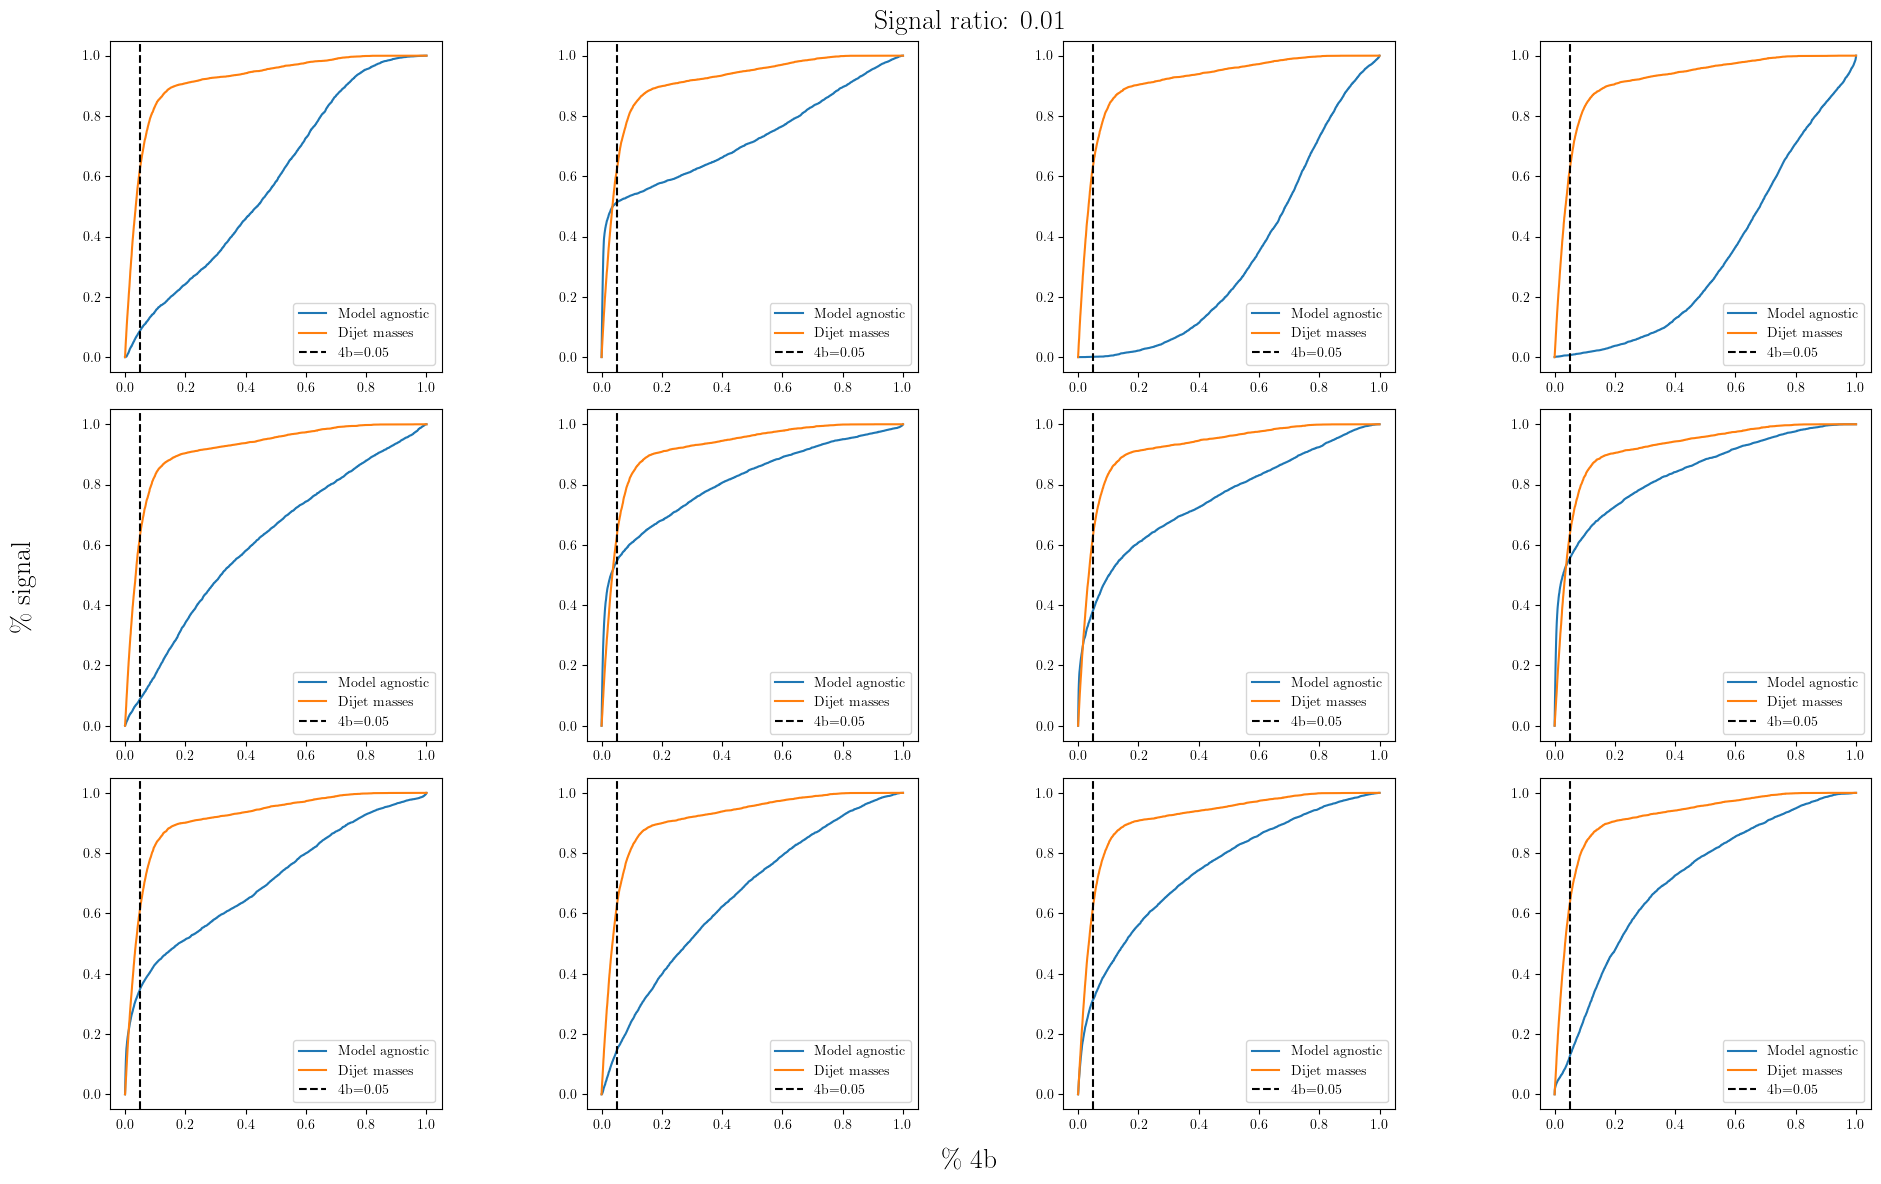

12it [02:22, 11.91s/it]


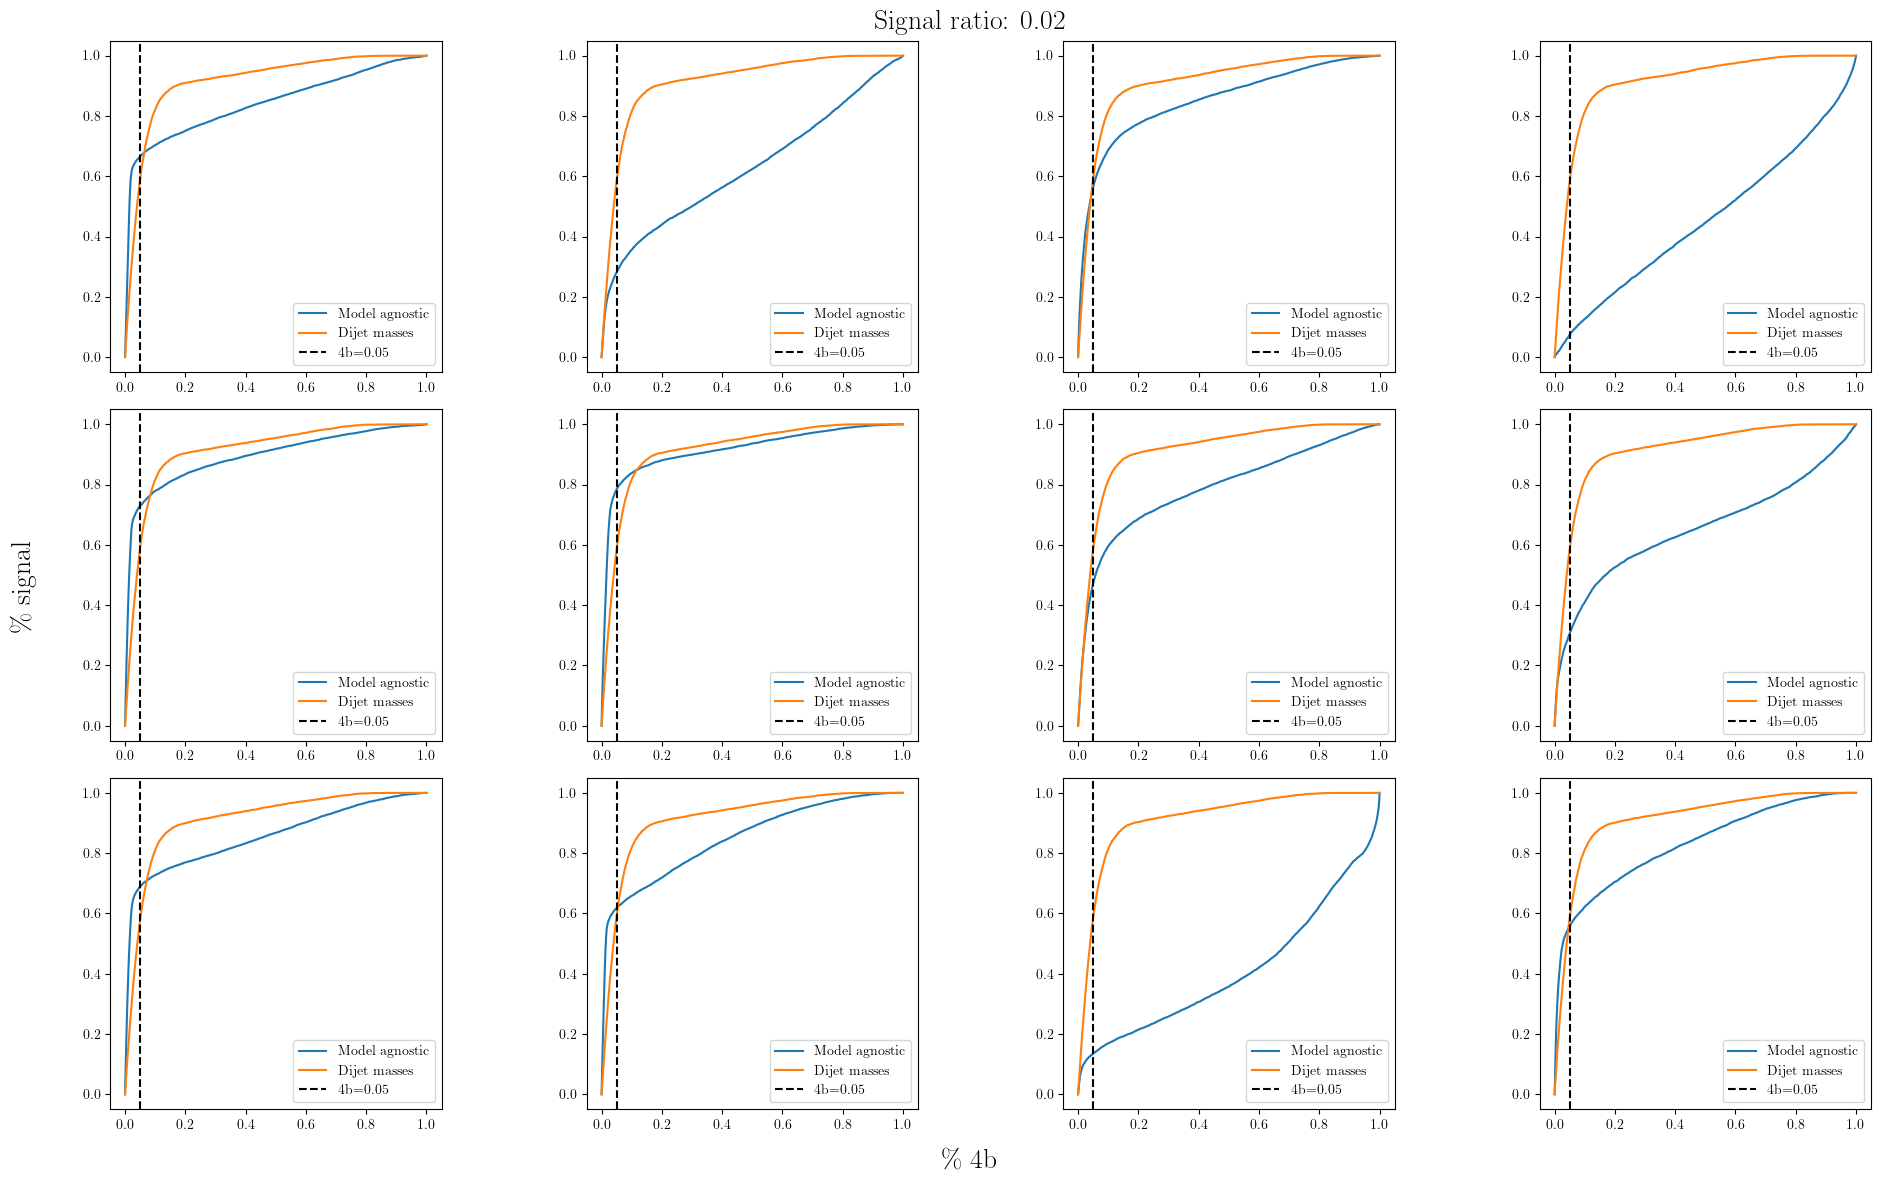

In [24]:
import pickle
from signal_region import get_SR_CR_cut, get_DRs
import pandas as pd
from plots import plot_sr_stats
from ancillary_features import get_closest_dijet_masses

n_3b = 100_0000
device = torch.device("cuda")
experiment_name = "CR_fvt_training"
signal_filename = "HH4b_picoAOD.h5"
ratio_4b = 0.5
seeds = np.arange(12)
nrows = 3
ncols = (len(seeds) + nrows - 1) // nrows
    

for signal_ratio in [0.01, 0.02]:
    fig = plt.figure(figsize=(ncols * 5, nrows * 4))
    fig.supxlabel("\% 4b")
    fig.supylabel("\% signal")
    fig.suptitle(f"Signal ratio: {signal_ratio}")
    gs = GridSpec(nrows, ncols, figure=fig)
    hparam_filter = {
        "experiment_name": experiment_name,
        "dataset": lambda x: all([x["seed"] in seeds, 
                            x["n_3b"] == n_3b, 
                            x["signal_ratio"] == signal_ratio]),
        "aux_info_step": 3
    }
    hashes = TrainingInfo.find(hparam_filter)

    for ax_cnt, hash in tqdm.tqdm(enumerate(hashes)):
        CR_fvt_tinfo = TrainingInfo.load(hash)
        smeared_fvt_hash = CR_fvt_tinfo.hparams["smeared_fvt_hash"]
        base_encoder_hash = CR_fvt_tinfo.hparams["encoder_hash"]

        base_fvt_model = TrainingInfo.load(base_encoder_hash).load_trained_model(
            CR_fvt_tinfo.hparams["encoder_mode"]
        )
        base_fvt_model.eval()
        base_fvt_model.to(torch.device("cuda"))

        smeared_fvt_tinfo = TrainingInfo.load(smeared_fvt_hash)
        smeared_fvt_model = smeared_fvt_tinfo.load_trained_model(
            CR_fvt_tinfo.hparams["encoder_mode"]
        )
        smeared_fvt_model.eval()
        smeared_fvt_model.to(torch.device("cuda"))

        # Use the same mother samples and exclude ones used for training base & smeared FvT model
        msamples = MotherSamples.load(smeared_fvt_tinfo.ms_hash)
        tst_scdinfo = msamples.scdinfo[~smeared_fvt_tinfo.ms_idx]
        events_tst = events_from_scdinfo(tst_scdinfo, features, signal_filename)
        gamma_base, gamma_smeared, q_repr_base = get_DRs(events_tst, base_fvt_model, smeared_fvt_model, return_repr=True)
        SR_stats = np.log(gamma_base / gamma_smeared)
        

        dm_0, dm_1 = get_closest_dijet_masses(events_tst.X_torch)
        dm_0, dm_1 = dm_0.numpy(), dm_1.numpy()
        m_H = 125
        SR_stats_dm = - np.sqrt((1 - m_H / dm_0)**2 + (1 - m_H / dm_1)**2)
        
        ax = fig.add_subplot(gs[ax_cnt // ncols, ax_cnt % ncols])
        

        np.cumsum(weights * is_4b) / np.sum(weights * is_4b),
        np.cumsum(weights * is_signal) / np.sum(weights * is_signal),
        plot_sr_stats(events_tst, SR_stats, ax, label="Model agnostic")
        plot_sr_stats(events_tst, SR_stats_dm, ax, label="Dijet masses")
        ax.set_aspect("equal")
        ax.axvline(0.05, color="black", linestyle="--", label="4b=0.05")
        ax.legend() 
    plt.tight_layout()
    plt.show()
    


In [18]:
import pickle
from signal_region import get_SR_CR_cut, get_DRs
import pandas as pd
from plots import plot_sr_stats
from ancillary_features import get_closest_dijet_masses

n_3b = 100_0000
device = torch.device("cuda")
experiment_name = "CR_fvt_training_v2"
signal_filename = "HH4b_picoAOD.h5"
ratio_4b = 0.5
seeds = np.arange(10)
nrows = 3
ncols = (len(seeds) + nrows - 1) // nrows

target_ratio_4b = np.arange(0, 1.01, 0.01)
signal_ratio = 0.02    

hparam_filter = {
    "experiment_name": experiment_name,
    "dataset": lambda x: all([x["seed"] in seeds, 
                        x["n_3b"] == n_3b, 
                        x["signal_ratio"] == signal_ratio]),
    "model": "FvTClassifier",
    "aux_info_step": 3
}
hashes = TrainingInfo.find(hparam_filter)

ratio_signal_interp = {"model_agnostic": [], "dijet_masses": []}

for ax_cnt, hash in tqdm.tqdm(enumerate(hashes)):
    CR_fvt_tinfo = TrainingInfo.load(hash)
    smeared_fvt_hash = CR_fvt_tinfo.hparams["smeared_fvt_hash"]
    smeared_fvt_tinfo = TrainingInfo.load(smeared_fvt_hash)
    
    # Use the same mother samples and exclude ones used for training base & smeared FvT model
    msamples = MotherSamples.load(smeared_fvt_tinfo.ms_hash)
    tst_scdinfo = msamples.scdinfo[~smeared_fvt_tinfo.ms_idx]
    events_tst = events_from_scdinfo(tst_scdinfo, features, signal_filename)
    SR_stats = smeared_fvt_tinfo.aux_info["SR_stats_tst"]

    dm_0, dm_1 = get_closest_dijet_masses(events_tst.X_torch)
    dm_0, dm_1 = dm_0.numpy(), dm_1.numpy()
    m_H = 125
    SR_stats_dm = - np.sqrt((1 - m_H / dm_0)**2 + (1 - m_H / dm_1)**2)
    
    for label, sr_stats in [("model_agnostic", SR_stats), ("dijet_masses", SR_stats_dm)]:
        sr_stats_argsort = np.argsort(sr_stats)[::-1]
        weights = events_tst.weights[sr_stats_argsort]
        is_signal = events_tst.is_signal[sr_stats_argsort]
        is_4b = events_tst.is_4b[sr_stats_argsort]

        ratio_4b = np.cumsum(weights * is_4b) / np.sum(weights * is_4b)
        ratio_signal = np.cumsum(weights * is_signal) / np.sum(weights * is_signal)
        ratio_4b_interp = np.interp(target_ratio_4b, ratio_4b, ratio_signal)
        
        ratio_signal_interp[label].append(ratio_4b_interp)

ratio_signal_interp["model_agnostic"] = np.array(ratio_signal_interp["model_agnostic"])
ratio_signal_interp["dijet_masses"] = np.array(ratio_signal_interp["dijet_masses"])

10it [00:51,  5.19s/it]


In [19]:
ratio_signal_interp["model_agnostic"] = np.array(ratio_signal_interp["model_agnostic"])
ratio_signal_interp["dijet_masses"] = np.array(ratio_signal_interp["dijet_masses"])

In [28]:
np.mean(ratio_signal_interp["dijet_masses"], axis=0)[::5]

array([1.89809100e-05, 5.87389070e-01, 8.15065053e-01, 8.83050994e-01,
       9.03700906e-01, 9.14089775e-01, 9.23286307e-01, 9.31625092e-01,
       9.39873767e-01, 9.48767805e-01, 9.57567292e-01, 9.65964109e-01,
       9.73582220e-01, 9.81617397e-01, 9.88494933e-01, 9.94502300e-01,
       9.98331457e-01, 9.99580091e-01, 9.99771935e-01, 9.99903113e-01,
       9.99999374e-01])

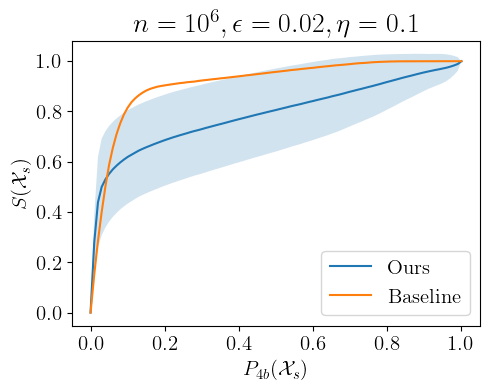

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.set_title(r"$n = 10^6, \epsilon = 0.02, \eta = 0.1$")
ax.set_xlabel(r"$P_{4b}(\mathcal{X}_s)$")
ax.set_ylabel(r"$S(\mathcal{X}_s)$")
for label in ["model_agnostic", "dijet_masses"]:
    ax.plot(target_ratio_4b, np.mean(ratio_signal_interp[label], axis=0), label="Ours" if label == "model_agnostic" else "Baseline")
    ax.fill_between(target_ratio_4b, 
                    np.mean(ratio_signal_interp[label], axis=0) - np.std(ratio_signal_interp[label], axis=0),
                    np.mean(ratio_signal_interp[label], axis=0) + np.std(ratio_signal_interp[label], axis=0),
                    alpha=0.2)
ax.legend(fontsize=15)
ax.tick_params(labelsize=15)
plt.tight_layout()
plt.savefig("figures/SR_comparison.pdf", dpi=300)
plt.show()


  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:41<00:00,  4.17s/it]


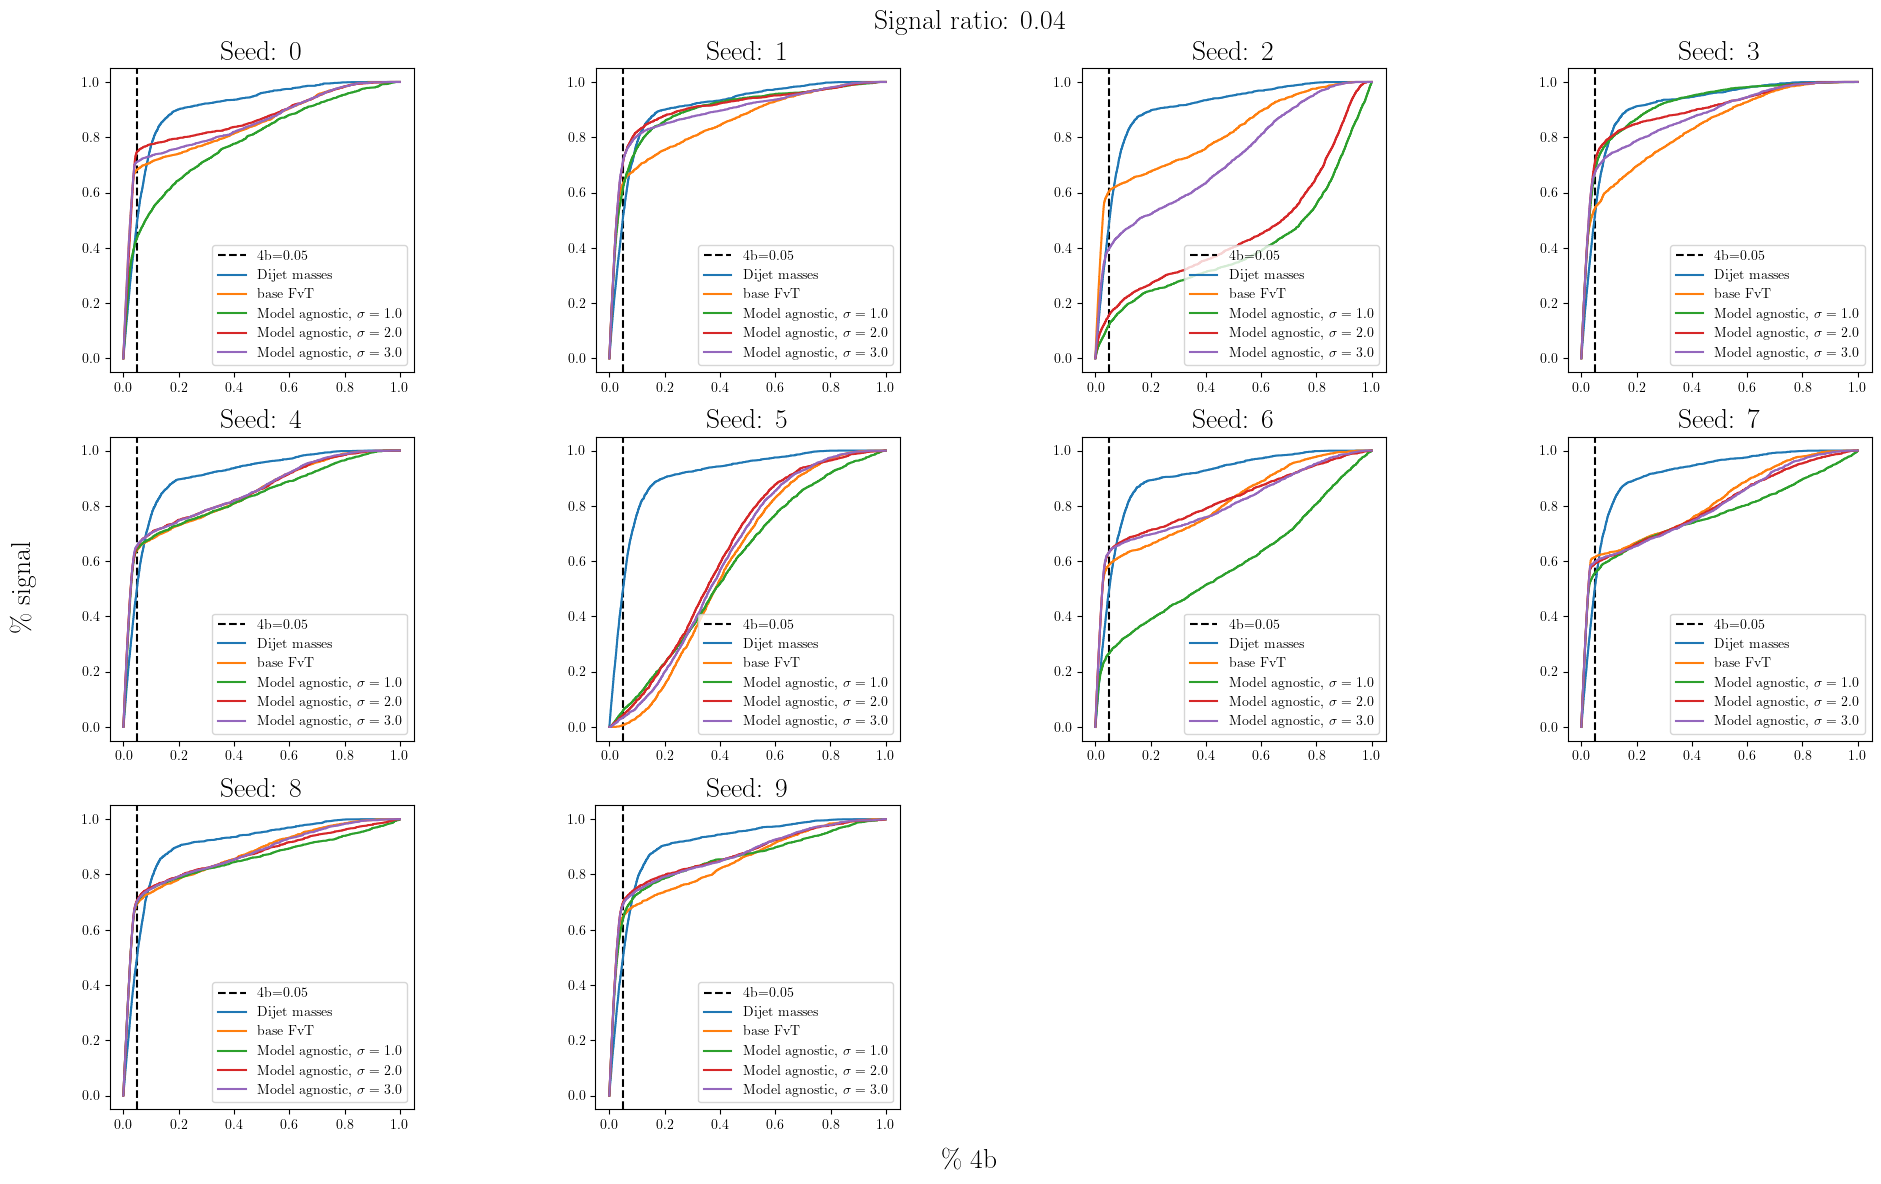

100%|██████████| 10/10 [00:41<00:00,  4.16s/it]


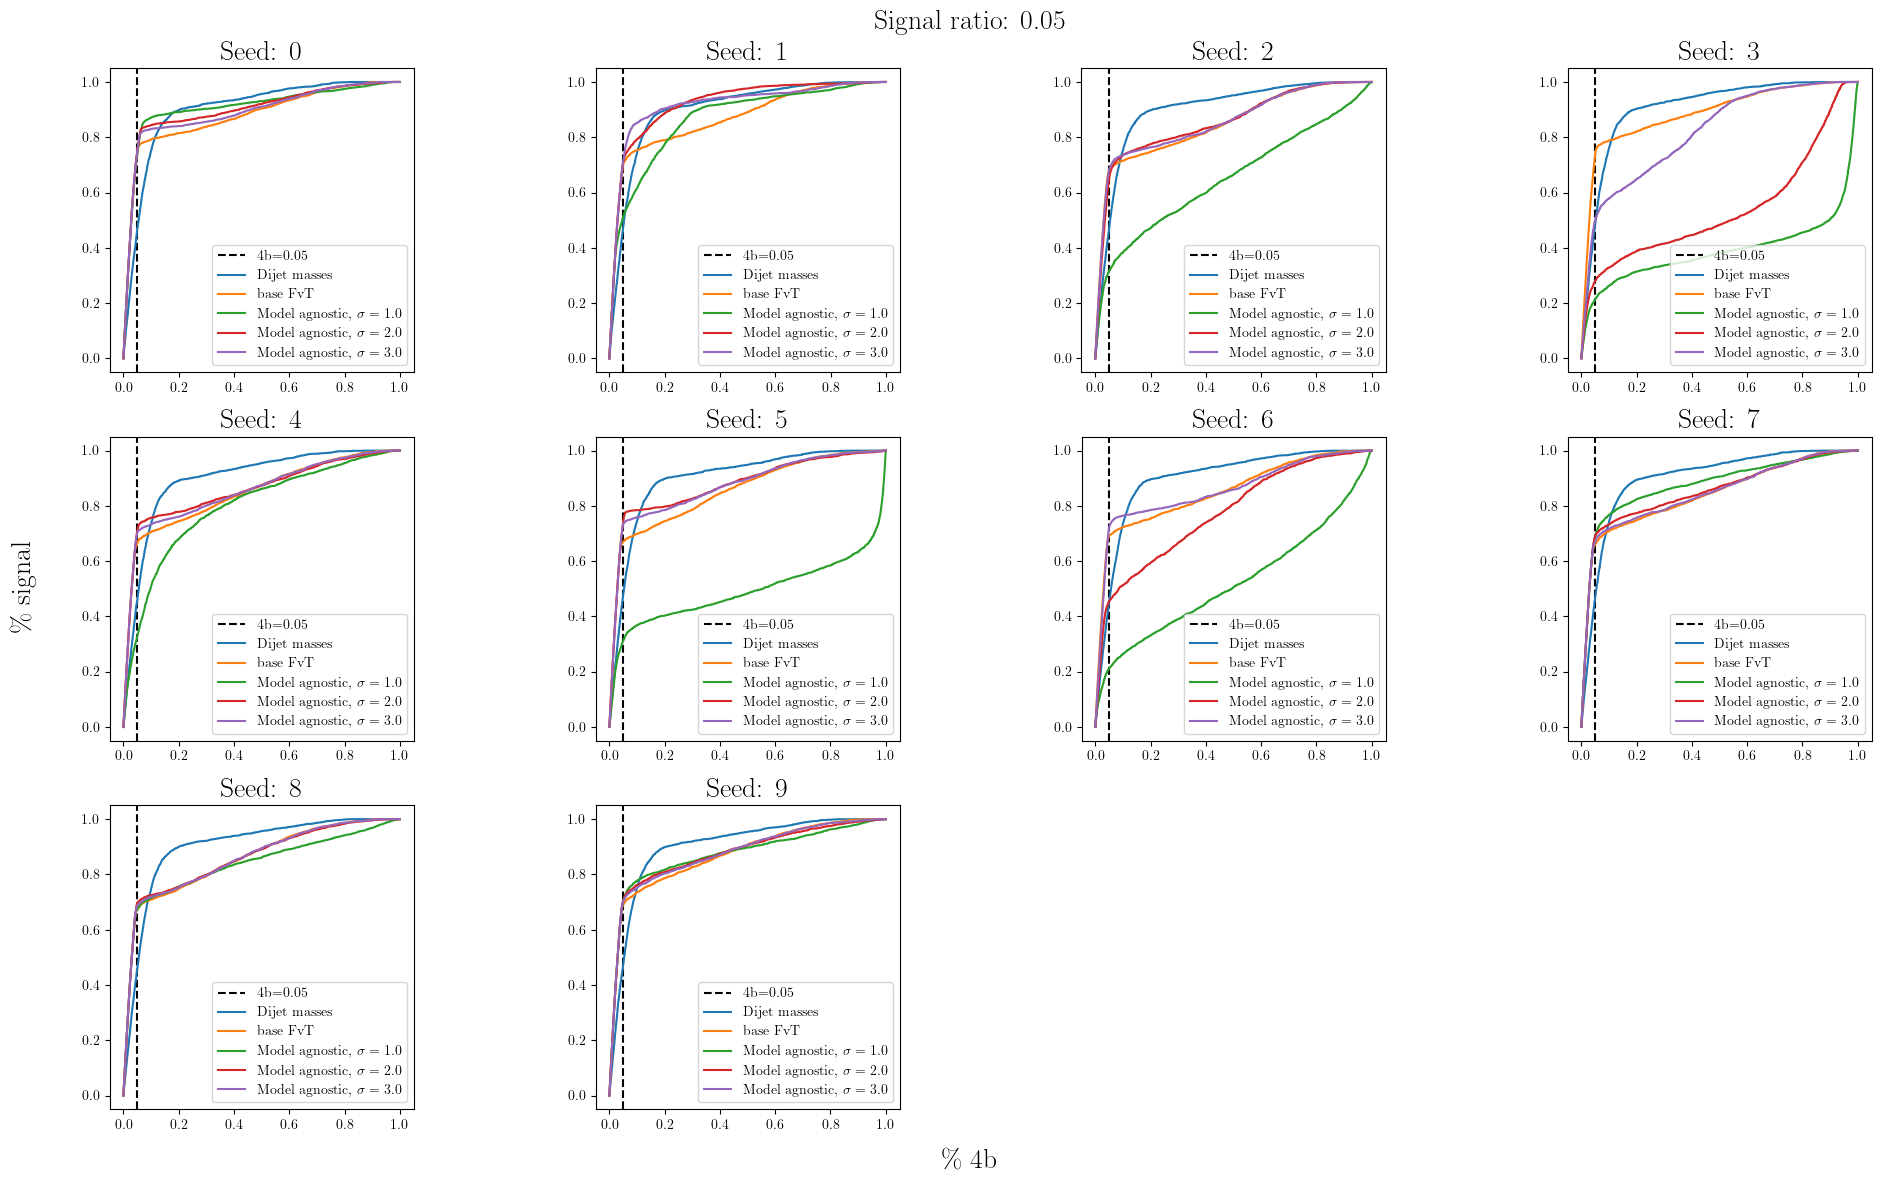

100%|██████████| 10/10 [00:41<00:00,  4.20s/it]


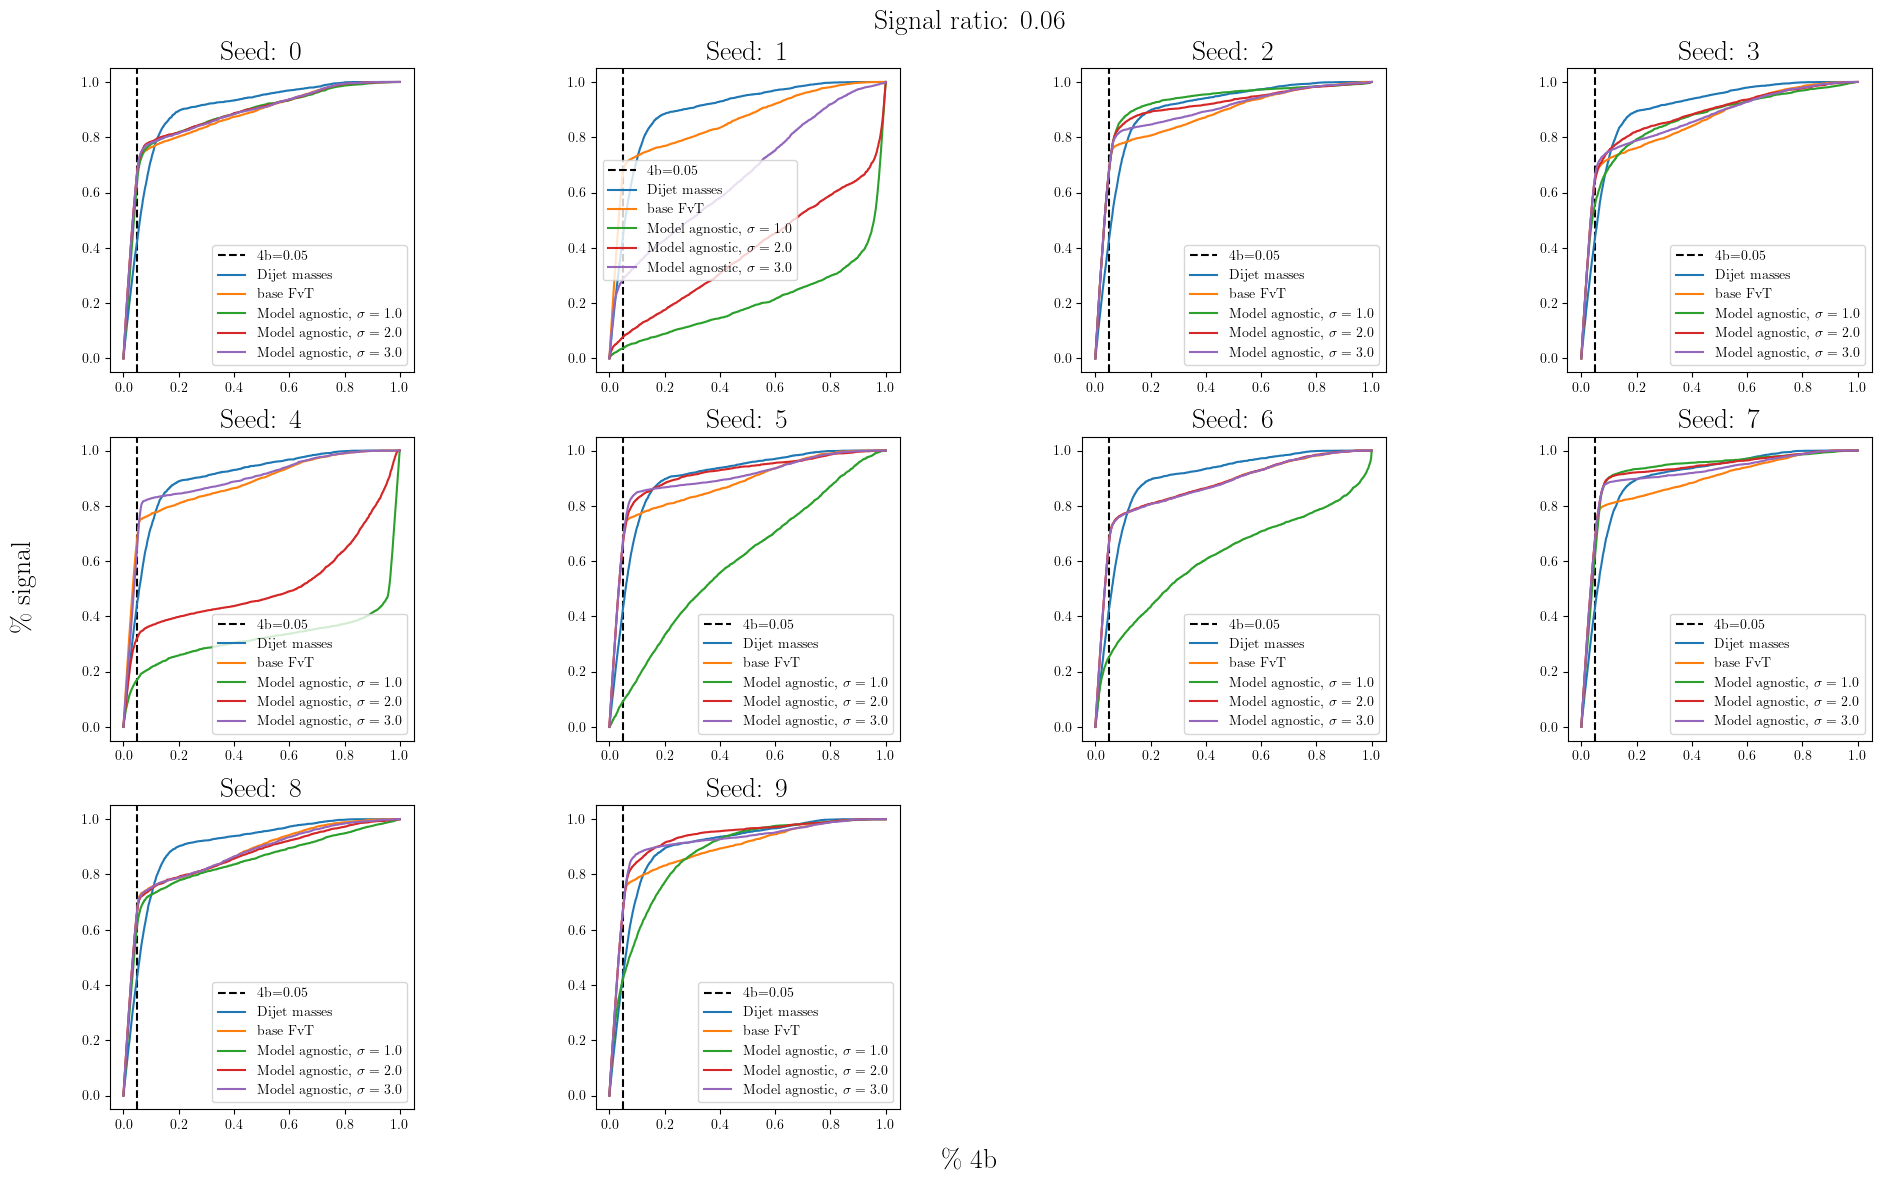

100%|██████████| 10/10 [00:41<00:00,  4.17s/it]


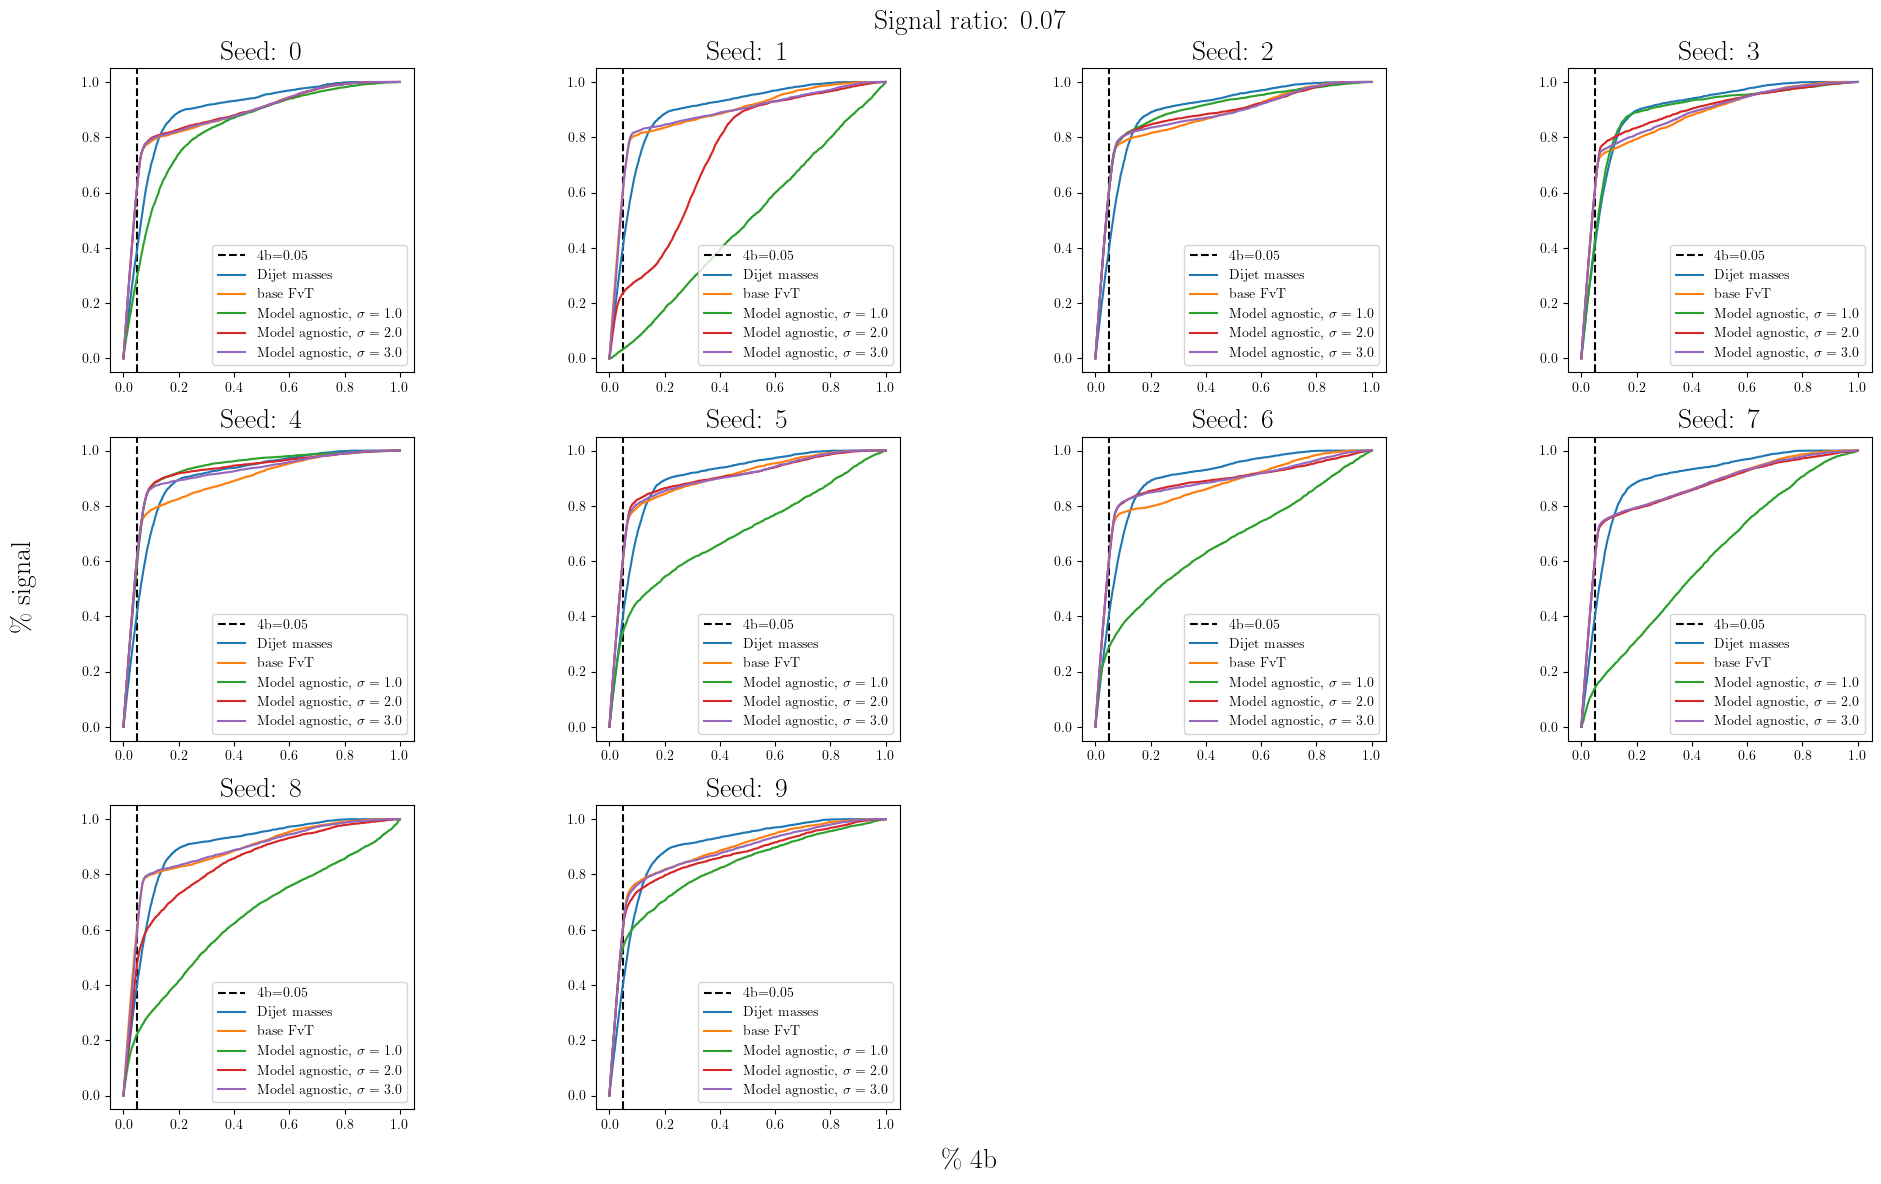

100%|██████████| 10/10 [00:41<00:00,  4.18s/it]


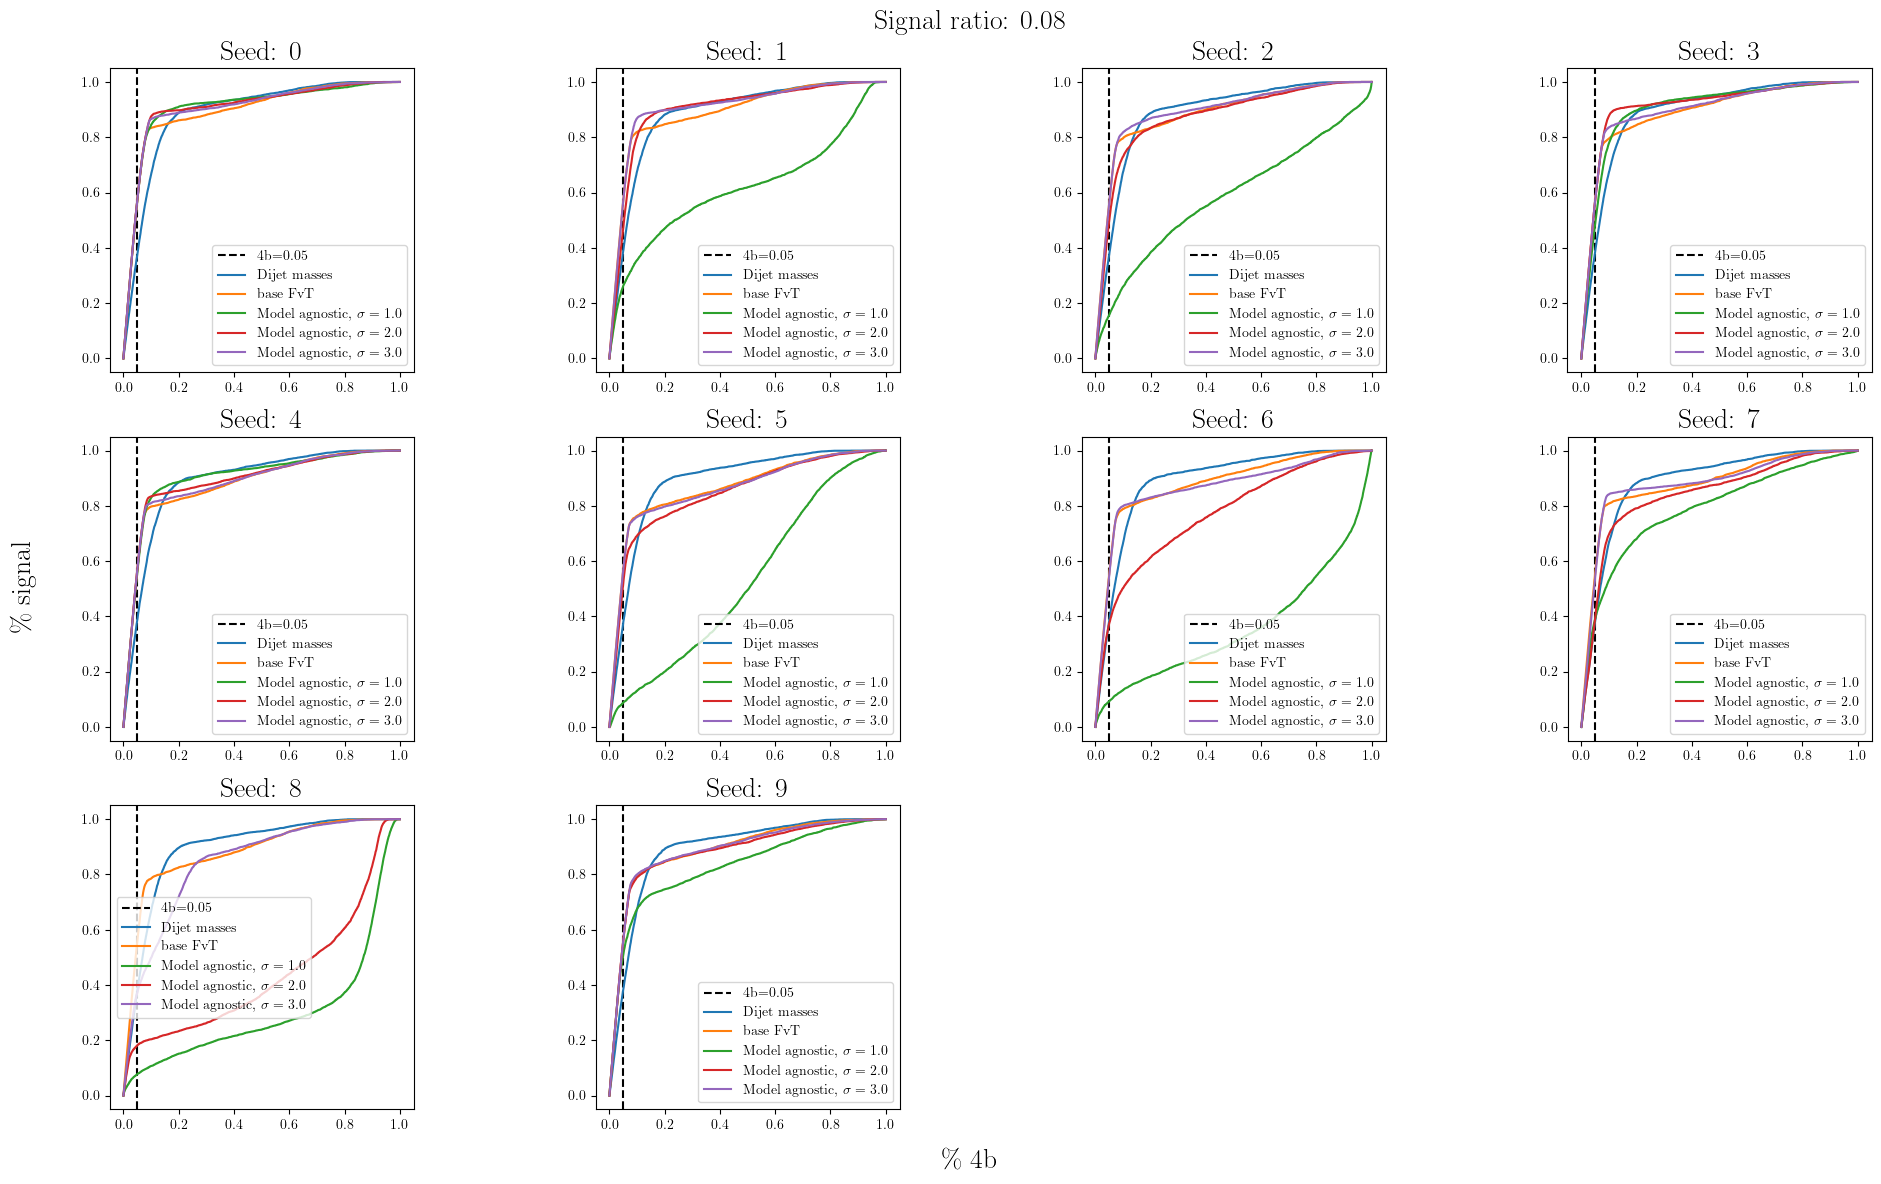

100%|██████████| 10/10 [00:41<00:00,  4.20s/it]


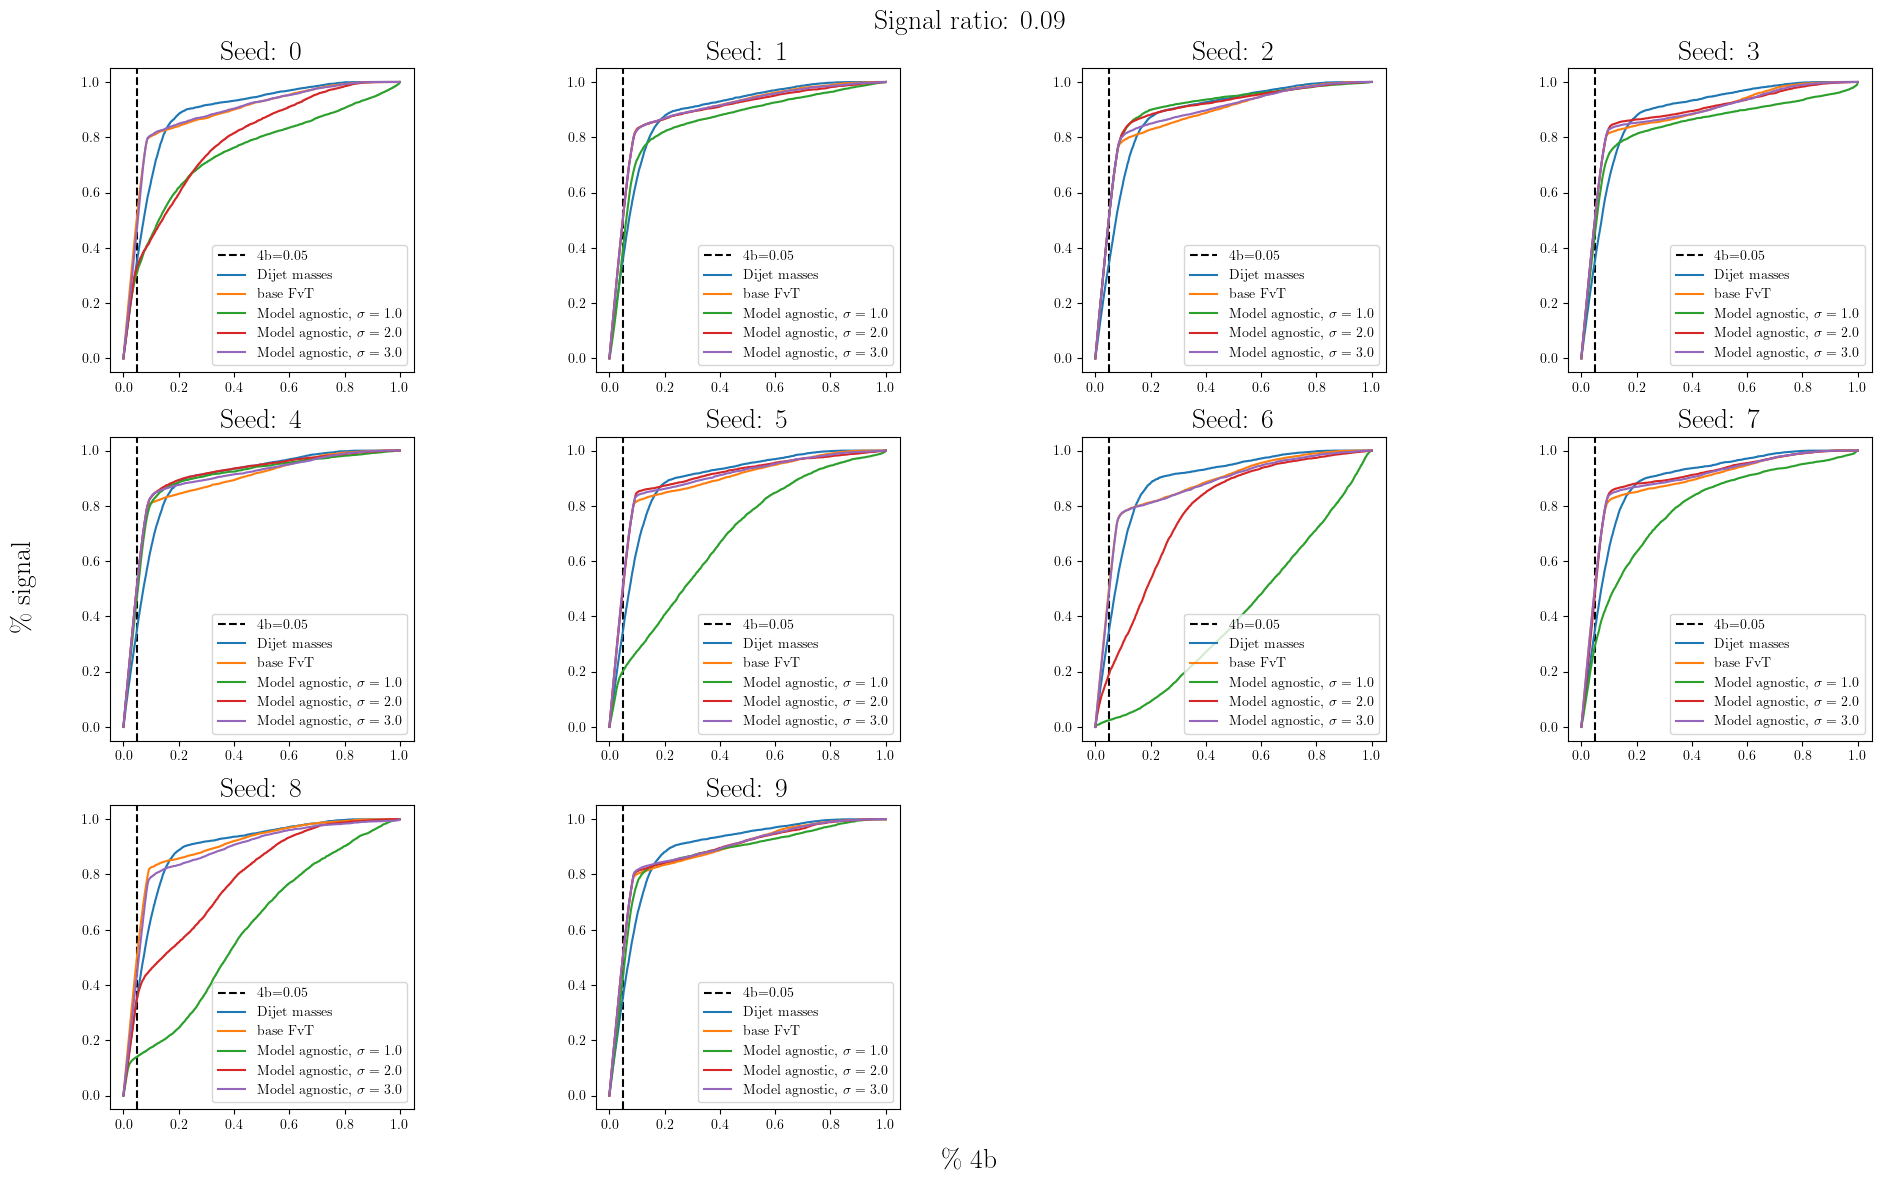

100%|██████████| 10/10 [00:42<00:00,  4.23s/it]


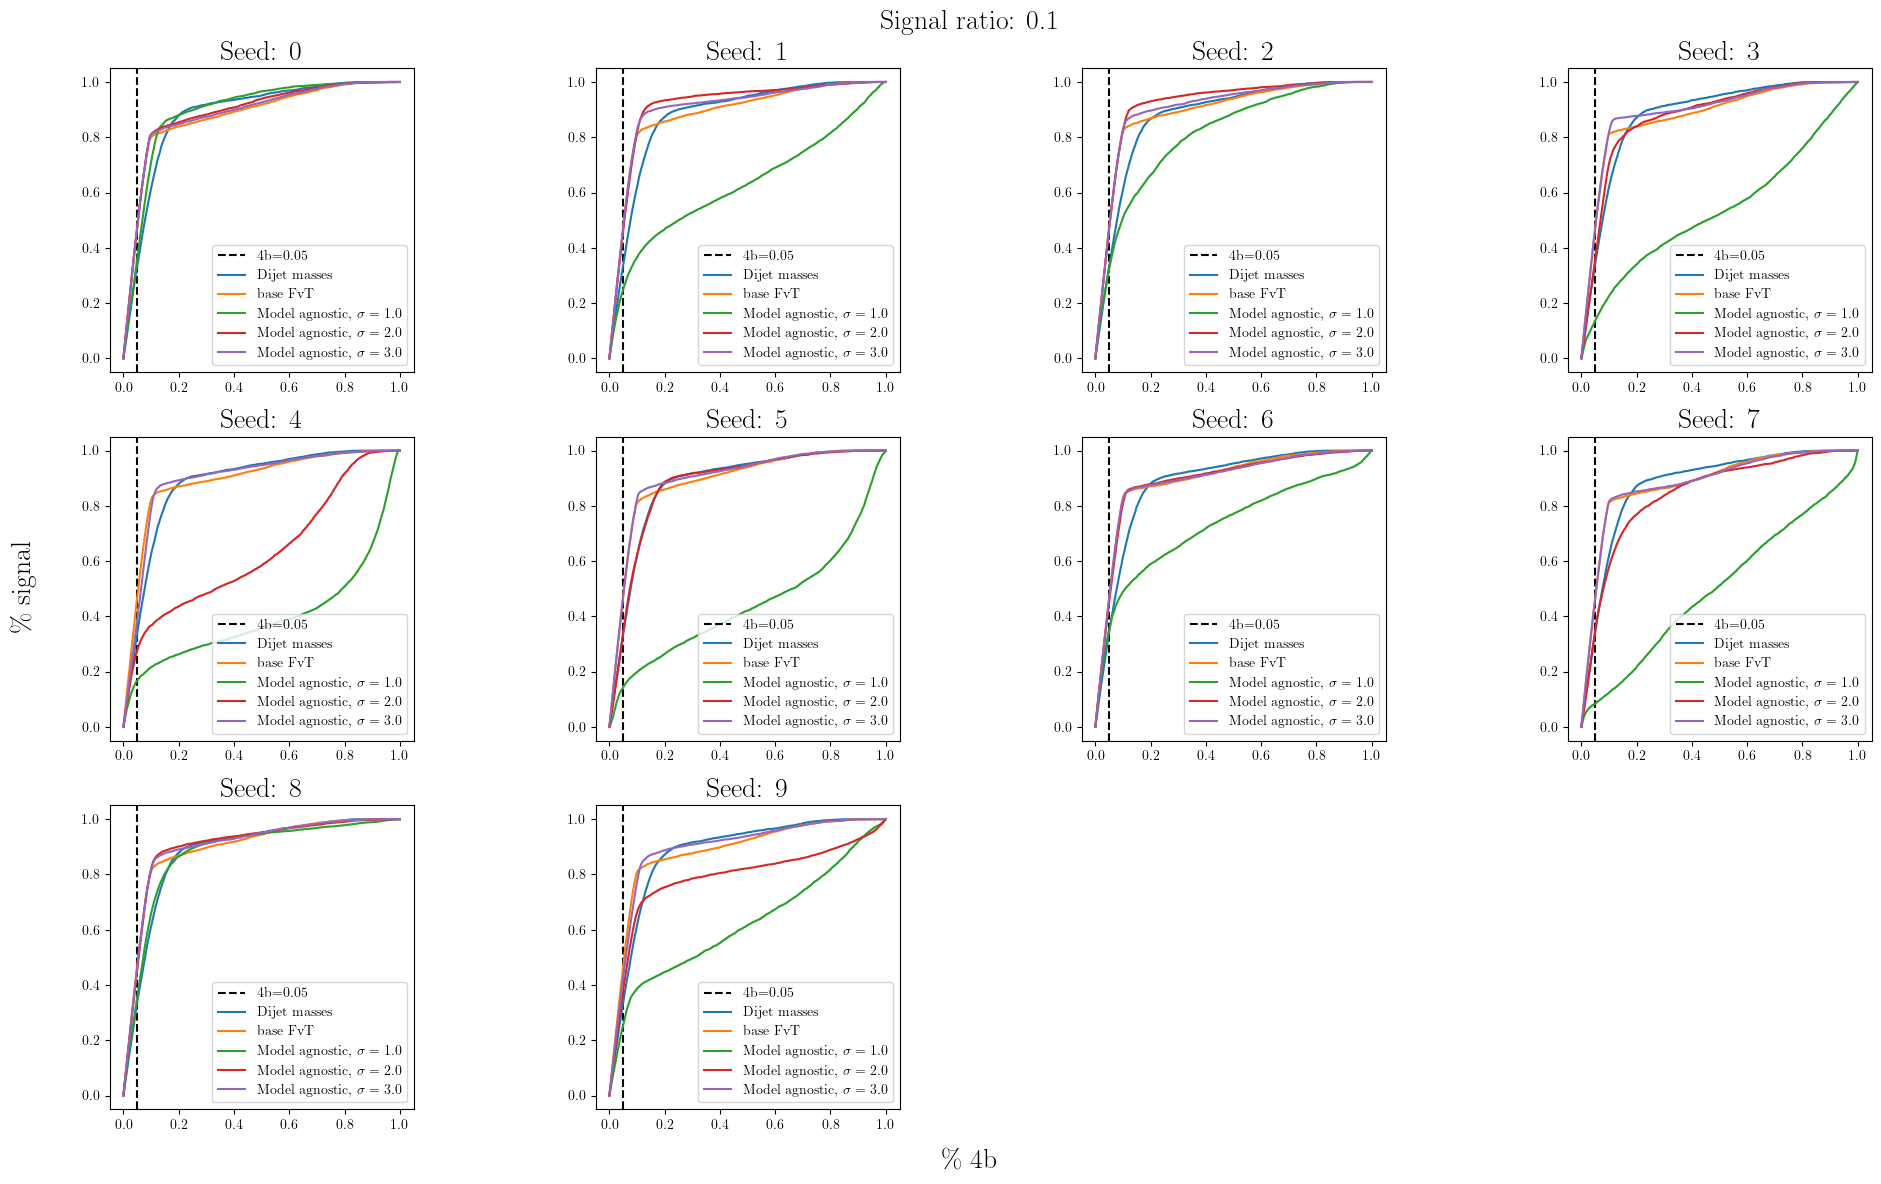

In [14]:
import pickle
from signal_region import get_SR_CR_cut, get_DRs
import pandas as pd
from plots import plot_sr_stats
from ancillary_features import get_closest_dijet_masses

n_3b = 100_000
device = torch.device("cuda")
experiment_name = "smeared_fvt_training_small"
signal_filename = "HH4b_picoAOD.h5"
ratio_4b = 0.5
seeds = np.arange(10)
nrows = 3
ncols = (len(seeds) + nrows - 1) // nrows
    

for signal_ratio in [0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]:
    
    fig = plt.figure(figsize=(ncols * 5, nrows * 4))
    fig.supxlabel("\% 4b")
    fig.supylabel("\% signal")
    fig.suptitle(f"Signal ratio: {signal_ratio}")
    gs = GridSpec(nrows, ncols, figure=fig)
    for seed in tqdm.tqdm(seeds):
        ax = fig.add_subplot(gs[seed // ncols, seed % ncols])
        ax.set_title(f"Seed: {seed}")
        ax.set_aspect("equal")
        ax.axvline(0.05, color="black", linestyle="--", label="4b=0.05")
        ax.legend() 

        hparam_filter = {
            "experiment_name": experiment_name,
            "dataset": lambda x: all([x["seed"] == seed, 
                                x["n_3b"] == n_3b, 
                                x["signal_ratio"] == signal_ratio]),
            "aux_info_step": 2, 
            # "smearing": lambda x: x["noise_scale"] == 2.0
        }
        hashes = TrainingInfo.find(hparam_filter)
        assert len(hashes) == 3, f"Expected 3 hashes for seed {seed}, got {len(hashes)}"
        
        smeared_fvt_tinfo = TrainingInfo.load(hashes[0])
        msamples = MotherSamples.load(smeared_fvt_tinfo.ms_hash)
        tst_scdinfo = msamples.scdinfo[~smeared_fvt_tinfo.ms_idx]
        events_tst = events_from_scdinfo(tst_scdinfo, features, signal_filename)

        for hash_idx, smeared_fvt_hash in enumerate(hashes):
            smeared_fvt_tinfo = TrainingInfo.load(smeared_fvt_hash)
            smeared_fvt_model = smeared_fvt_tinfo.load_trained_model(
                    smeared_fvt_tinfo.hparams["encoder_mode"]
                )
            smeared_fvt_model.eval()
            smeared_fvt_model.to(torch.device("cuda"))
            noise_scale = smeared_fvt_tinfo.hparams["smearing"]["noise_scale"]
            
            if hash_idx == 0:
                # calculate gamma_base
                base_encoder_hash = smeared_fvt_tinfo.hparams["encoder_hash"]

                base_fvt_model = TrainingInfo.load(base_encoder_hash).load_trained_model(
                    smeared_fvt_tinfo.hparams["encoder_mode"]
                )
                base_fvt_model.eval()
                base_fvt_model.to(torch.device("cuda"))

                # Use the same mother samples and exclude ones used for training base & smeared FvT model
                gamma_base, gamma_smeared, q_repr_base = get_DRs(events_tst, base_fvt_model, smeared_fvt_model, return_repr=True)    
                
                dm_0, dm_1 = get_closest_dijet_masses(events_tst.X_torch)
                dm_0, dm_1 = dm_0.numpy(), dm_1.numpy()
                m_H = 125
                SR_stats_dm = - np.sqrt((1 - m_H / dm_0)**2 + (1 - m_H / dm_1)**2)
                            
                plot_sr_stats(events_tst, SR_stats_dm, ax, label="Dijet masses")
                plot_sr_stats(events_tst, gamma_base / (1 + gamma_base), ax, label="base FvT")
                
            else:
                # only need to compute gamma_smeared
                fvt_smeared = smeared_fvt_model.predict(q_repr_base)[:, 1].detach().cpu().numpy()
                gamma_smeared = fvt_smeared / (1 - fvt_smeared)
            
            SR_stats = np.log(gamma_base / gamma_smeared)                
            plot_sr_stats(events_tst, SR_stats, ax, label=f"Model agnostic, $\sigma={noise_scale}$")
            
        ax.legend()
            
    plt.tight_layout()
    plt.show()
        


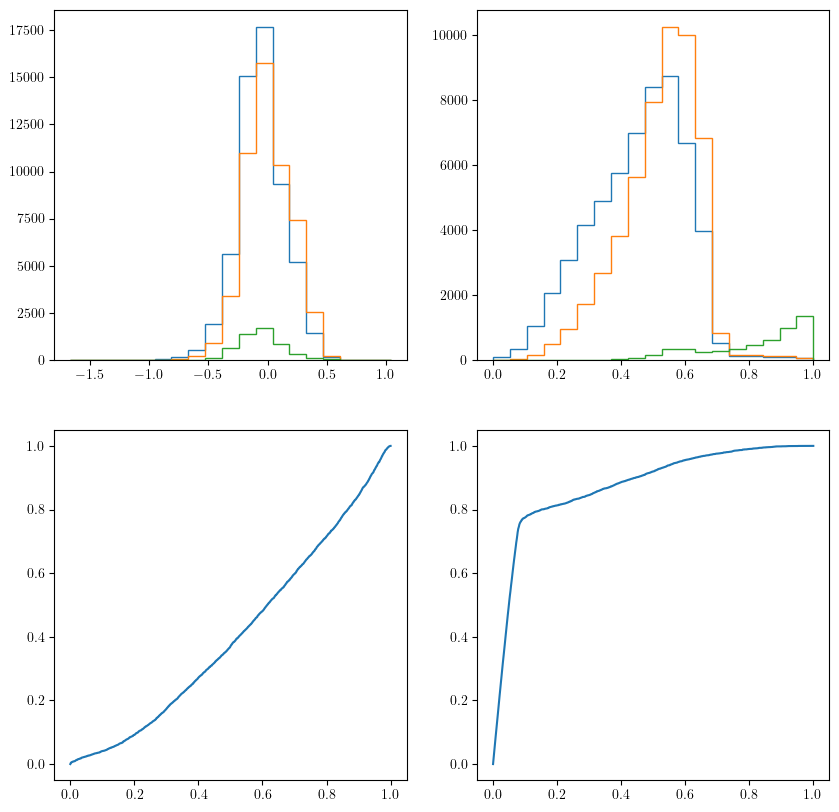

In [6]:
import pickle
from signal_region import get_SR_CR_cut, get_DRs
import pandas as pd
from plots import plot_sr_stats
from ancillary_features import get_closest_dijet_masses

n_3b = 100_000
device = torch.device("cuda")
experiment_name = "smeared_fvt_training_small"
signal_filename = "HH4b_picoAOD.h5"
ratio_4b = 0.5

signal_ratio = 0.09
seed = 6
hparam_filter = {
    "experiment_name": experiment_name,
    "dataset": lambda x: all([x["seed"] == seed, 
                        x["n_3b"] == n_3b, 
                        x["signal_ratio"] == signal_ratio]),
    "aux_info_step": 2
}
hashes = TrainingInfo.find(hparam_filter)
smeared_fvt_hash = hashes[0]

smeared_fvt_tinfo = TrainingInfo.load(smeared_fvt_hash)
base_encoder_hash = smeared_fvt_tinfo.hparams["encoder_hash"]

base_fvt_model = TrainingInfo.load(base_encoder_hash).load_trained_model(
    smeared_fvt_tinfo.hparams["encoder_mode"]
)
base_fvt_model.eval()
base_fvt_model.to(torch.device("cuda"))

smeared_fvt_model = smeared_fvt_tinfo.load_trained_model(
    smeared_fvt_tinfo.hparams["encoder_mode"]
)
smeared_fvt_model.eval()
smeared_fvt_model.to(torch.device("cuda"))

# Use the same mother samples and exclude ones used for training base & smeared FvT model
msamples = MotherSamples.load(smeared_fvt_tinfo.ms_hash)
tst_scdinfo = msamples.scdinfo[~smeared_fvt_tinfo.ms_idx]
events_tst = events_from_scdinfo(tst_scdinfo, features, signal_filename)
gamma_base, gamma_smeared, q_repr_base = get_DRs(events_tst, base_fvt_model, smeared_fvt_model, return_repr=True)
SR_stats = np.log(gamma_base / gamma_smeared)

fig, ax = plt.subplots(2, 2, figsize=(10, 10))
bins = np.linspace(np.min(SR_stats), np.max(SR_stats), 20)
hist_events_by_labels(events_tst, SR_stats, bins=bins, ax=ax[0, 0])
hist_events_by_labels(events_tst, gamma_base / (1 + gamma_base), bins=np.linspace(0, 1, 20), ax=ax[0, 1])
plot_sr_stats(events_tst, SR_stats, ax=ax[1, 0], label="Model agnostic")
plot_sr_stats(events_tst, gamma_base / (1 + gamma_base), ax=ax[1, 1], label="Model agnostic")
plt.show() 
